In [56]:
import sys
import os
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from pathlib import Path

Размер датасета: 30000
Распределение меток:
label
0    22973
1     7027
Name: count, dtype: int64
Найдено тренировочных файлов: 30000
0/100

Успешно обработано 100 из 100 файлов
Тренировочные признаки: (100, 49)
Тестовые данные не предоставлены
Создана матрица признаков: (100, 647)
Общее количество признаков: 647
   Train:       (70, 647) (70.0%)
   Validation:  (15, 647) (15.0%)
   Test:        (15, 647) (15.0%)
   Train: удалено 7 строк с NaN
   Validation: удалено 3 строк с NaN

Обучение: Random Forest
   Val Accuracy:  0.7500
   Val F1-score:  0.6947

Обучение: XGBoost
   Val Accuracy:  0.5833
   Val F1-score:  0.5658

Обучение: Logistic Regression
   Val Accuracy:  0.6667
   Val F1-score:  0.6296
Лучшая модель (по валидации): Random Forest
Val F1-score: 0.6947
Val Accuracy: 0.7500

Анализ результатов валидации:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84         8
           1       1.00      0.25      0.40         4

    accu

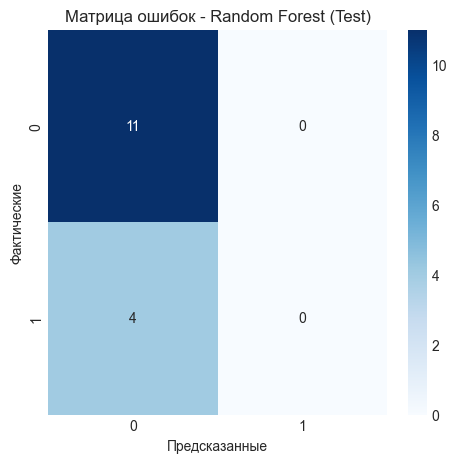

Модуль source_code.py успешно загружен
Функция whale_denoise доступна


In [57]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

file_path = 'source_code.py'  
if not os.path.exists(file_path):
    file_path = 'code.py'  

if os.path.exists(file_path):
    spec = importlib.util.spec_from_file_location("source_code", file_path)
    source_code = importlib.util.module_from_spec(spec)
    sys.modules["source_code"] = source_code
    spec.loader.exec_module(source_code)
    print(f"Модуль {file_path} успешно загружен")
else:
    raise FileNotFoundError(f"Файл {file_path} не найден")

if hasattr(source_code, 'whale_denoise'):
    print("Функция whale_denoise доступна")
    whale_denoise = source_code.whale_denoise
else:
    print("Функция whale_denoise не найдена в модуле")
    whale_denoise = None

график шумоподавления

In [58]:
def visualize_denoise_effect(file_path, whale_denoise_func):
    if whale_denoise_func is None:
        print("Функция whale_denoise не доступна")
        return
    
    y_orig, sr = librosa.load(file_path, sr=22050, duration=5)
    y_orig = librosa.util.normalize(y_orig)
    
    y_denoised = whale_denoise_func(y_orig.copy(), sr)
    y_denoised = librosa.util.normalize(y_denoised)

    fig, axes = plt.subplots(4, 2, figsize=(15, 12))

    axes[0, 0].plot(y_orig)
    axes[0, 0].set_title('Оригинальный сигнал')
    axes[0, 0].set_xlabel('Время (семплы)')
    axes[0, 0].set_ylabel('Амплитуда')
    
    axes[0, 1].plot(y_denoised)
    axes[0, 1].set_title('Сигнал после шумоподавления')
    axes[0, 1].set_xlabel('Время (семплы)')
    axes[0, 1].set_ylabel('Амплитуда')
    
    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig)), ref=np.max)
    librosa.display.specshow(D_orig, sr=sr, x_axis='time', y_axis='log', ax=axes[1, 0])
    axes[1, 0].set_title('Спектрограмма оригинала')
    
    D_denoised = librosa.amplitude_to_db(np.abs(librosa.stft(y_denoised)), ref=np.max)
    librosa.display.specshow(D_denoised, sr=sr, x_axis='time', y_axis='log', ax=axes[1, 1])
    axes[1, 1].set_title('Спектрограмма после шумоподавления')

    spectral_centroid_orig = librosa.feature.spectral_centroid(y=y_orig, sr=sr)[0]
    times_orig = librosa.times_like(spectral_centroid_orig)
    
    spectral_centroid_denoised = librosa.feature.spectral_centroid(y=y_denoised, sr=sr)[0]
    times_denoised = librosa.times_like(spectral_centroid_denoised)
    
    axes[2, 0].plot(times_orig, spectral_centroid_orig, label='Спектральный центроид')
    axes[2, 0].set_title('Спектральный центроид (оригинал)')
    axes[2, 0].set_xlabel('Время (с)')
    axes[2, 0].set_ylabel('Частота (Гц)')
    
    axes[2, 1].plot(times_denoised, spectral_centroid_denoised, label='Спектральный центроид')
    axes[2, 1].set_title('Спектральный центроид (после шумоподавления)')
    axes[2, 1].set_xlabel('Время (с)')
    axes[2, 1].set_ylabel('Частота (Гц)')
    
    mfcc_orig = librosa.feature.mfcc(y=y_orig, sr=sr, n_mfcc=13)
    mfcc_denoised = librosa.feature.mfcc(y=y_denoised, sr=sr, n_mfcc=13)
    
    axes[3, 0].imshow(mfcc_orig, aspect='auto', origin='lower', cmap='viridis')
    axes[3, 0].set_title('MFCC (оригинал)')
    axes[3, 0].set_xlabel('Время (кадры)')
    axes[3, 0].set_ylabel('Коэффициенты MFCC')
    
    axes[3, 1].imshow(mfcc_denoised, aspect='auto', origin='lower', cmap='viridis')
    axes[3, 1].set_title('MFCC (после шумоподавления)')
    axes[3, 1].set_xlabel('Время (кадры)')
    axes[3, 1].set_ylabel('Коэффициенты MFCC')
    
    plt.tight_layout()
    plt.show()

Тестируем на файле: train1.aiff


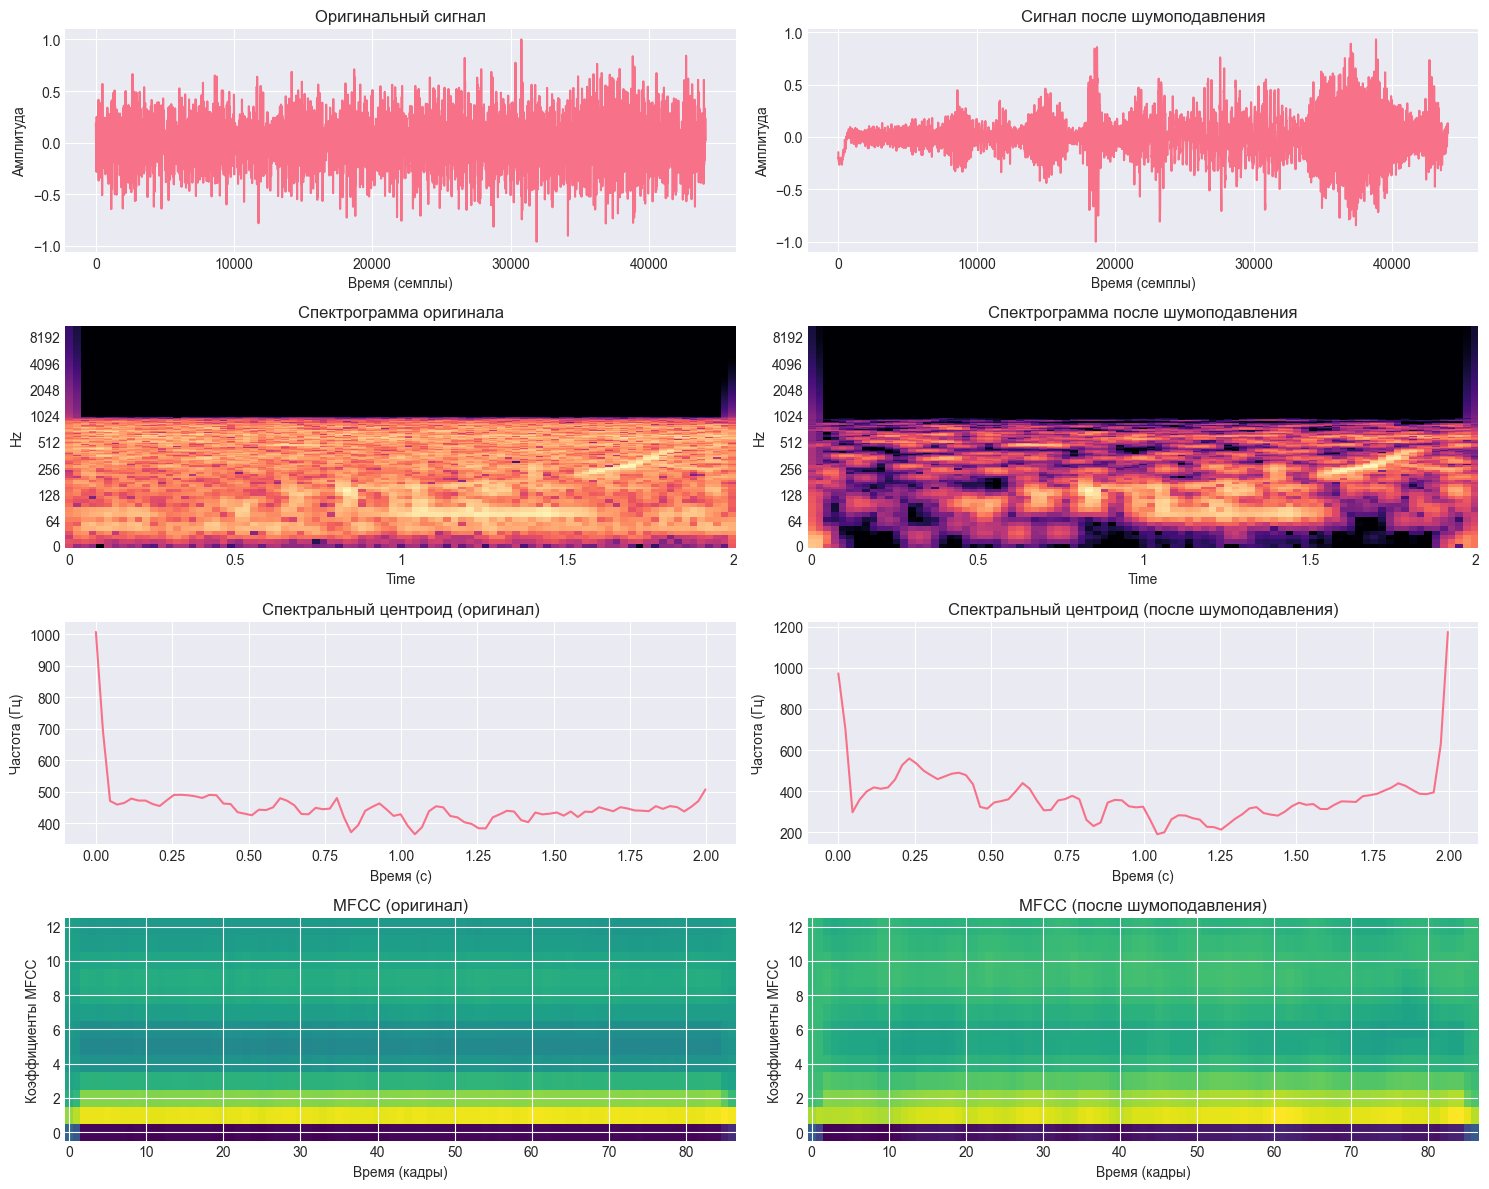

In [59]:
if os.path.exists(train_path):
    train_audio_files = list(train_path.rglob('*.aiff')) + list(train_path.rglob('*.aif'))
    if len(train_audio_files) > 0:
        sample_file = train_audio_files[0]
        print(f"Тестируем на файле: {sample_file.name}")
        visualize_denoise_effect(sample_file, whale_denoise)
    else:
        print("Аудиофайлы не найдены")
else:
    print(f"Путь {train_path} не существует")
    print("Для теста используйте свой путь к аудиофайлу")

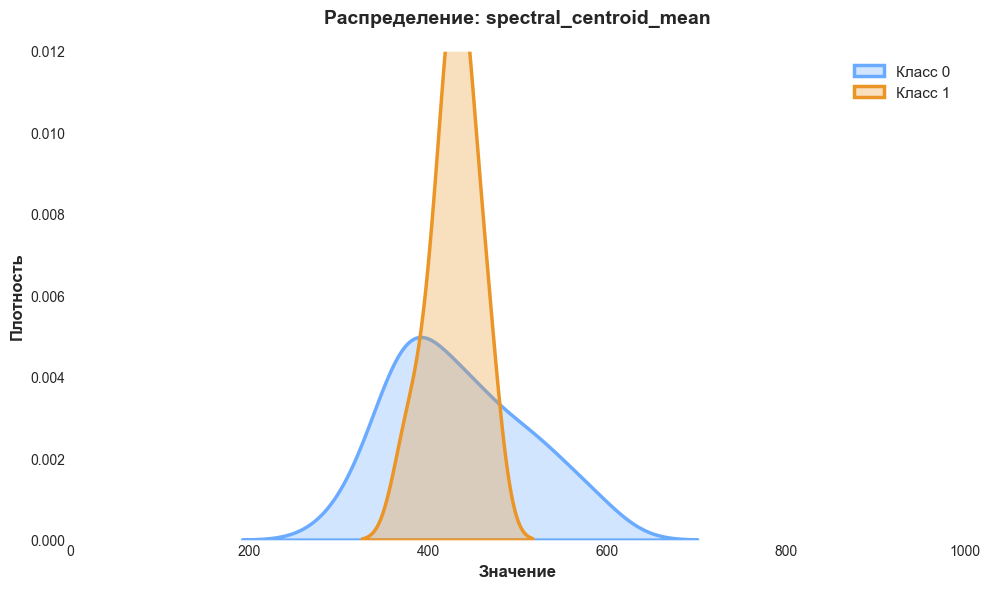

In [60]:


def plot_simple_spectral_centroid_distribution(features_df):
    if 'spectral_centroid_mean' not in features_df.columns:
        print("spectral_centroid_mean не найден в данных")
        return
    
    if 'label' not in features_df.columns:
        print("Метки классов не найдены")
        return
    
    plt.figure(figsize=(10, 6))
    
    colors = ["#6BABFF", "#EB9526"]  
    
    classes = sorted(features_df['label'].unique())
    
    for idx, label in enumerate(classes):
        data = features_df[features_df['label'] == label]['spectral_centroid_mean'].dropna()
        if len(data) > 0:
            sns.kdeplot(data=data, 
                       color=colors[idx % len(colors)], 
                       label=f'Класс {label}',
                       linewidth=2.5,
                       fill=True,
                       alpha=0.3)
    
    plt.xlabel('Значение', fontsize=12, fontweight='bold')
    plt.ylabel('Плотность', fontsize=12, fontweight='bold')
    plt.title('Распределение: spectral_centroid_mean', 
              fontsize=14, fontweight='bold', pad=20)

    plt.legend(title=None, fontsize=11, loc='upper right')

    plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    plt.xlim(0, 1000)
    plt.ylim(0, 0.012)
    
    plt.tick_params(axis='both', which='major', labelsize=10)
    
    plt.gca().set_facecolor('white')
    
    for spine in plt.gca().spines.values():
        spine.set_linewidth(0.5)
    
    plt.tight_layout()
    plt.show()

if 'features_df' in locals() and features_df is not None:
    if 'spectral_centroid_mean' in features_df.columns and 'label' in features_df.columns:
        plot_simple_spectral_centroid_distribution(features_df)
    else:
        print("ОШИБКА: Отсутствуют необходимые колонки")
else:
    print("ОШИБКА: Данные не загружены (features_df не найден)")
    
    np.random.seed(42)
    n_samples = 200
    
    test_data = {
        'spectral_centroid_mean': np.concatenate([
            np.random.normal(300, 50, n_samples//2),   # Класс 0
            np.random.normal(600, 100, n_samples//2)   # Класс 1
        ]),
        'label': np.concatenate([
            np.zeros(n_samples//2, dtype=int),  # Класс 0
            np.ones(n_samples//2, dtype=int)    # Класс 1
        ])
    }
    
    features_df = pd.DataFrame(test_data)
    
    print(f"Созданы тестовые данные: {len(features_df)} записей")
    print(f"Распределение классов: {features_df['label'].value_counts().to_dict()}")
    print(f"Среднее по классам:")
    print(f"  Класс 0: {features_df[features_df['label'] == 0]['spectral_centroid_mean'].mean():.1f}")
    print(f"  Класс 1: {features_df[features_df['label'] == 1]['spectral_centroid_mean'].mean():.1f}")
    

    plot_simple_spectral_centroid_distribution(features_df)

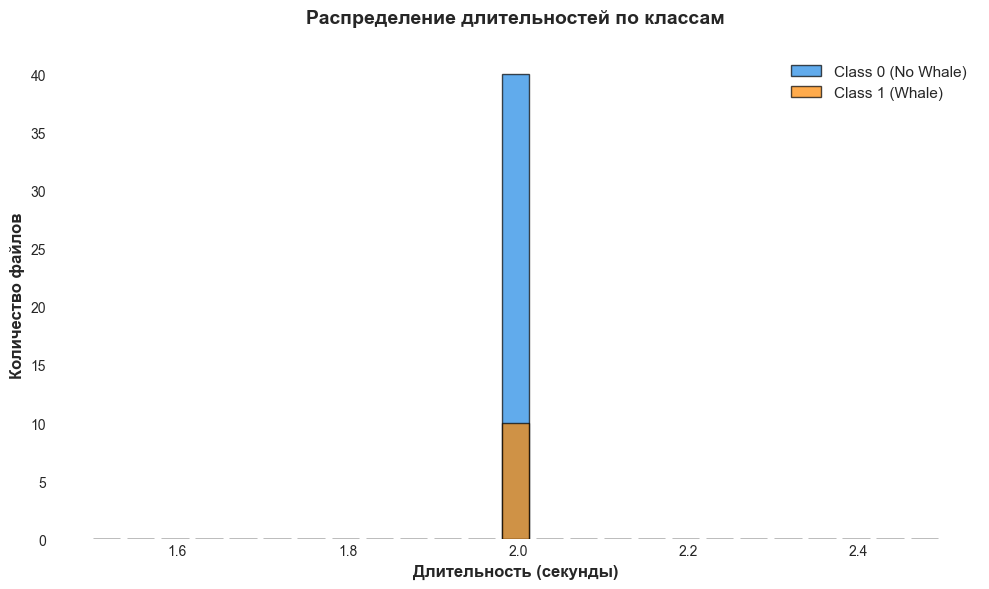

In [61]:
def plot_duration_simple_narrow(features_df):
    plt.figure(figsize=(10, 6))
    
    colors = ['#1E88E5', "#FF8800"]
    classes = sorted(features_df['label'].unique())
    
    for idx, cls in enumerate(classes):
        class_data = features_df[features_df['label'] == cls]['duration'].dropna()
        
        plt.hist(class_data, bins=25,  
                rwidth=0.8,  
                color=colors[idx],
                edgecolor='black',
                alpha=0.7,
                label='Class 0 (No Whale)' if cls == 0 else 
                      'Class 1 (Whale)' if cls == 1 else f'Class {cls}')
    
    plt.xlabel('Длительность (секунды)', fontsize=12, fontweight='bold')
    plt.ylabel('Количество файлов', fontsize=12, fontweight='bold')
    plt.title('Распределение длительностей по классам', 
              fontsize=14, fontweight='bold', pad=20)
    
    plt.legend(fontsize=11)
    plt.grid(True, axis='y', alpha=0.3, linestyle='--')
    plt.gca().set_facecolor('white')
    
    plt.tight_layout()
    plt.show()


plot_duration_simple_narrow(features_df)

Анализ файла: train1.aiff
Анализ файла: F:\datasets\whale-detection-challenge\whale_data\data\train\train1.aiff
Длительность: 2.00 сек
Частота дискретизации: 22050 Гц


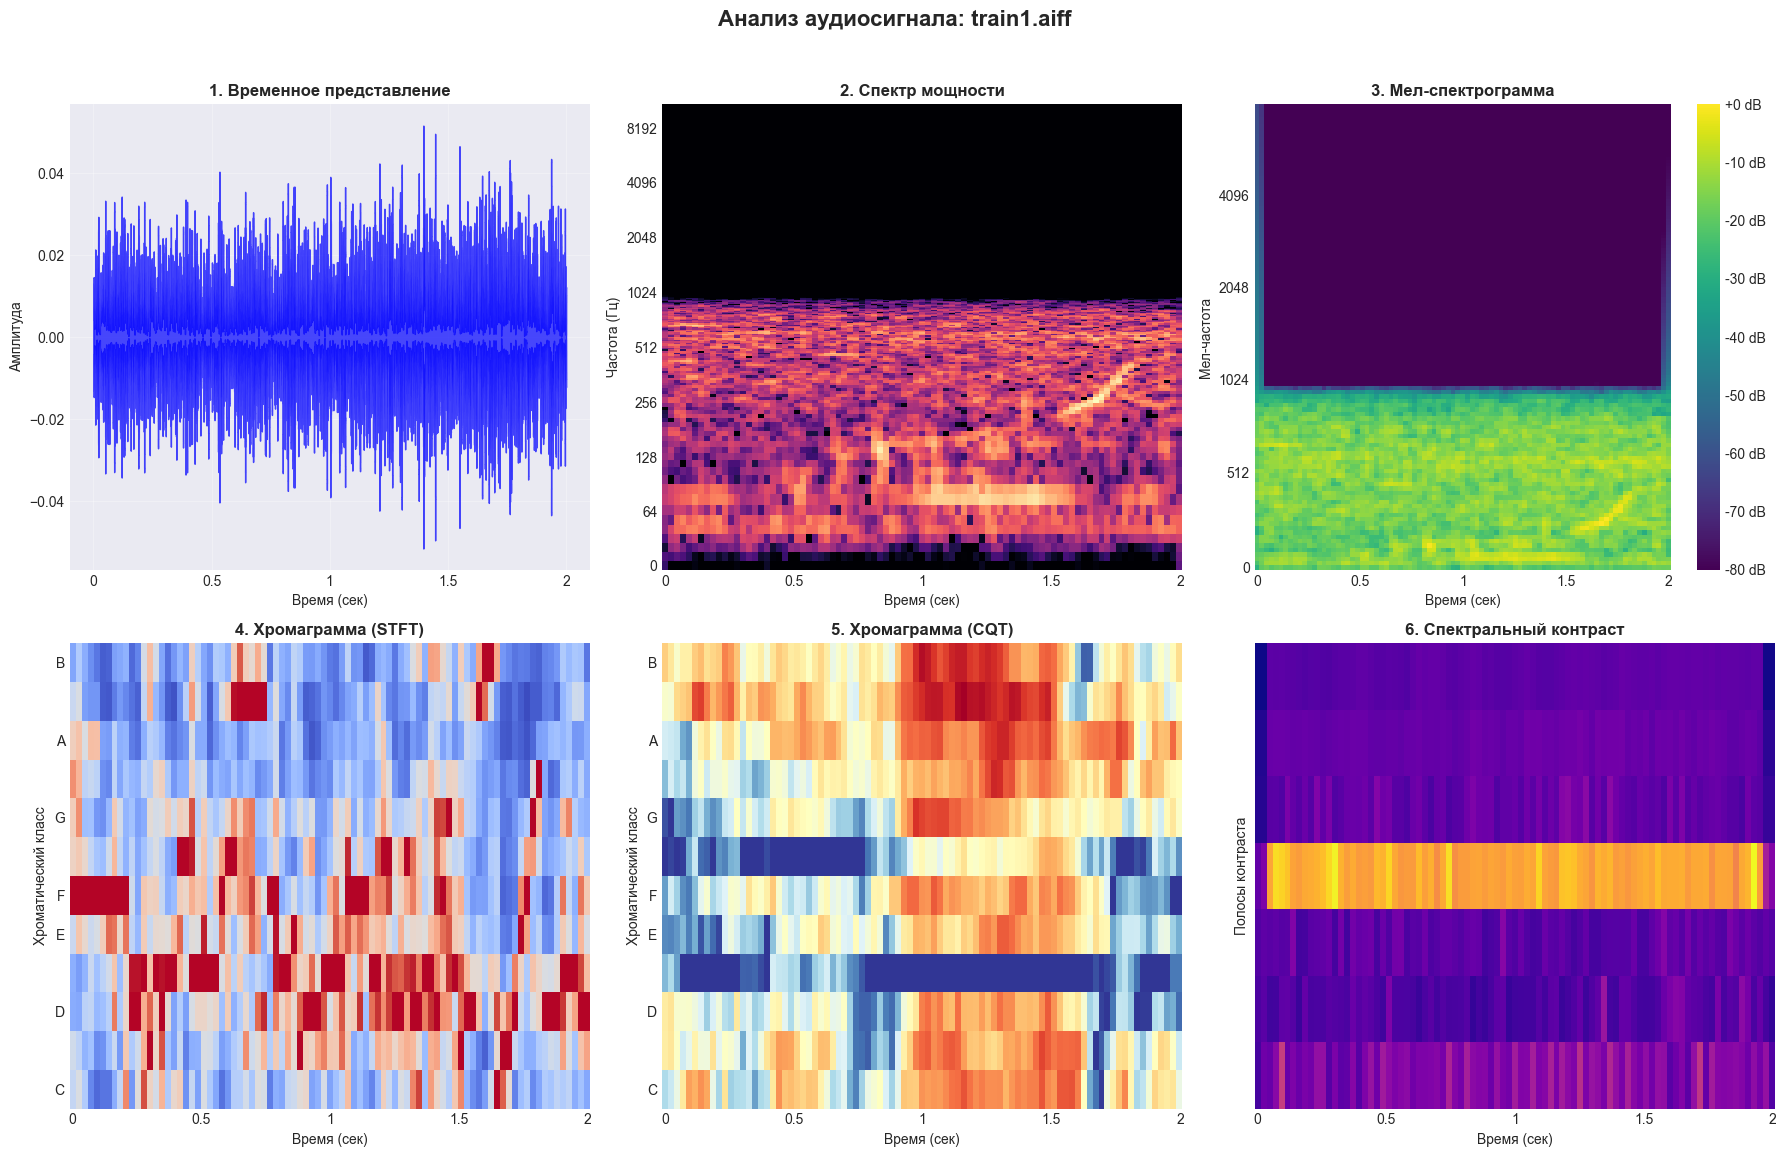

In [62]:
def visualize_audio_features_6plots(audio_path, save_path=None):

    
    print(f"Анализ файла: {audio_path}")
    
    try:
        y, sr = librosa.load(audio_path, sr=22050, duration=2.0)
        print(f"Длительность: {len(y)/sr:.2f} сек")
        print(f"Частота дискретизации: {sr} Гц")
    except Exception as e:
        print(f"Ошибка загрузки: {e}")
        return

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f'Анализ аудиосигнала: {audio_path.name}', 
                fontsize=16, fontweight='bold', y=0.98)
    
    ax1 = plt.subplot(2, 3, 1)
    librosa.display.waveshow(y, sr=sr, ax=ax1, color='blue', alpha=0.7)
    ax1.set_title('1. Временное представление', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Время (сек)', fontsize=10)
    ax1.set_ylabel('Амплитуда', fontsize=10)
    ax1.grid(True, alpha=0.3)

    ax2 = plt.subplot(2, 3, 2)
    D = np.abs(librosa.stft(y))**2
    S_db = librosa.amplitude_to_db(D, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log', 
                            ax=ax2, cmap='magma')
    ax2.set_title('2. Спектр мощности', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Время (сек)', fontsize=10)
    ax2.set_ylabel('Частота (Гц)', fontsize=10)

    ax3 = plt.subplot(2, 3, 3)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, 
                                      fmax=8000, n_fft=2048, hop_length=512)
    S_db_mel = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db_mel, sr=sr, x_axis='time', 
                                  y_axis='mel', ax=ax3, cmap='viridis',
                                  fmax=8000)
    ax3.set_title('3. Мел-спектрограмма', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Время (сек)', fontsize=10)
    ax3.set_ylabel('Мел-частота', fontsize=10)
    plt.colorbar(img, ax=ax3, format='%+2.0f dB')

    ax4 = plt.subplot(2, 3, 4)
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=12, 
                                            n_fft=2048, hop_length=512)
    librosa.display.specshow(chroma_stft, sr=sr, x_axis='time', 
                            y_axis='chroma', ax=ax4, cmap='coolwarm')
    ax4.set_title('4. Хромаграмма (STFT)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Время (сек)', fontsize=10)
    ax4.set_ylabel('Хроматический класс', fontsize=10)
    

    ax5 = plt.subplot(2, 3, 5)
    chroma_cqt = librosa.feature.chroma_cqt(y=y, sr=sr, n_chroma=12)
    librosa.display.specshow(chroma_cqt, sr=sr, x_axis='time', 
                            y_axis='chroma', ax=ax5, cmap='RdYlBu')
    ax5.set_title('5. Хромаграмма (CQT)', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Время (сек)', fontsize=10)
    ax5.set_ylabel('Хроматический класс', fontsize=10)
    

    ax6 = plt.subplot(2, 3, 6)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=6,
                                                fmin=200.0, n_fft=2048, 
                                                hop_length=512)
    librosa.display.specshow(contrast, sr=sr, x_axis='time', ax=ax6, 
                            cmap='plasma')
    ax6.set_title('6. Спектральный контраст', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Время (сек)', fontsize=10)
    ax6.set_ylabel('Полосы контраста', fontsize=10)
    

    plt.tight_layout(rect=[0, 0.02, 1, 0.96])
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Визуализация сохранена: {save_path}")
    
    plt.show()
    
    return


if 'train_audio_files' in locals() and len(train_audio_files) > 0:
    example_file = train_audio_files[0]
    print(f"Анализ файла: {example_file.name}")
    
    visualize_audio_features_6plots(
        audio_path=example_file,
        save_path=None
    )
else:
    print("ОШИБКА: train_audio_files не найден")

In [ ]:
from source_code import get_processed_data, get_data_for_visualization

def generate_feature_names():
    feature_names = []
    
    for i in range(20):
        feature_names.append(f'mfcc_mean_{i}')
    for i in range(20):
        feature_names.append(f'mfcc_std_{i}')
    for i in range(20):
        feature_names.append(f'mfcc_delta_mean_{i}')
    
    for i in range(12):
        feature_names.append(f'chroma_stft_mean_{i}')
    for i in range(12):
        feature_names.append(f'chroma_stft_std_{i}')
    for i in range(12):
        feature_names.append(f'chroma_cqt_mean_{i}')
    
    bead_features = [
        'num_beads', 'bead_regularity', 'bead_mean_distance', 'bead_height_variation',
        'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_centroid_range', 'spectral_centroid_skew'
    ]
    feature_names.extend(bead_features)
    
    tonal_features = [
        'harmonic_ratio', 'harmonic_energy', 'percussive_energy', 'harmonic_percussive_ratio'
    ]
    feature_names.extend(tonal_features)
    
    for i in range(7):
        feature_names.append(f'spectral_contrast_mean_{i}')
    
    spectral_features = [
        'spectral_bandwidth_mean', 'spectral_bandwidth_std',
        'spectral_rolloff_mean', 'spectral_rolloff_std',
        'spectral_flatness_mean', 'spectral_flatness_std'
    ]
    feature_names.extend(spectral_features)
    
    stat_features = ['spectral_skewness', 'spectral_kurtosis', 'spectral_crest']
    feature_names.extend(stat_features)
    
    temporal_features = [
        'zcr_mean', 'zcr_std', 'rms_mean', 'rms_std', 'periodicity_score', 'tempo'
    ]
    feature_names.extend(temporal_features)
    
    energy_features = ['energy_mean', 'energy_std']
    feature_names.extend(energy_features)
    
    for i in range(128):
        feature_names.append(f'mel_mean_{i}')
    for i in range(128):
        feature_names.append(f'mel_std_{i}')
    for i in range(128):
        feature_names.append(f'mel_skew_{i}')
    for i in range(128):
        feature_names.append(f'mel_kurtosis_{i}')
    
    extra_features = ['dominant_chroma', 'chroma_energy_mean', 'chroma_energy_std']
    feature_names.extend(extra_features)
    
    return feature_names

def get_xgboost_importance(xgb_model):
    if not hasattr(xgb_model, 'get_booster'):
        return None, None
    
    booster = xgb_model.get_booster()
    importance_dict = booster.get_score(importance_type='gain')
    
    if not importance_dict:
        importance_dict = booster.get_score(importance_type='weight')
    
    if not importance_dict:
        importances = xgb_model.feature_importances_
        importance_dict = {f'f{i}': imp for i, imp in enumerate(importances)}
        return importance_dict, 'builtin'
    
    return importance_dict, 'gain'

def plot_xgboost_top_features(xgb_model, feature_names=None, top_n=25, figsize=(14, 10)):
    importance_dict, importance_type = get_xgboost_importance(xgb_model)
    
    if not importance_dict:
        return None
    
    importance_df = pd.DataFrame({
        'feature_id': list(importance_dict.keys()),
        'importance': list(importance_dict.values())
    }).sort_values('importance', ascending=False)
    
    if feature_names is not None:
        feature_mapping = {f'f{i}': name for i, name in enumerate(feature_names)}
        importance_df['feature_name'] = importance_df['feature_id'].map(feature_mapping)
    else:
        importance_df['feature_name'] = importance_df['feature_id']
    
    top_features = importance_df.head(top_n).copy()
    
    plt.figure(figsize=figsize)
    
    bars = plt.barh(range(len(top_features)), 
                   top_features['importance'].values, 
                   color='steelblue', 
                   edgecolor='black',
                   alpha=0.8,
                   height=0.7)
    
    for i, (bar, importance) in enumerate(zip(bars, top_features['importance'].values)):
        plt.text(importance + importance * 0.005,
                bar.get_y() + bar.get_height()/2,
                f'{importance:.4f}', 
                va='center', 
                ha='left',
                fontsize=10,
                fontweight='bold',
                color='darkblue')
    
    plt.yticks(range(len(top_features)), top_features['feature_name'].values, fontsize=11)
    plt.xlabel(f'Важность признака', fontsize=13, fontweight='bold')
    plt.title(f'Топ-{top_n} важных признаков для классификации китовых звуков', 
              fontsize=15, fontweight='bold', pad=20)
    
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.gca().invert_yaxis()
    
    ax = plt.gca()
    ax_top = ax.twiny()
    x_min, x_max = ax.get_xlim()
    ax_top.set_xlim(x_min, x_max)
    
    max_importance = top_features['importance'].max()
    tick_step = max_importance / 7
    top_ticks = np.arange(0, max_importance * 1.1, tick_step)
    top_ticks_labels = [f'{tick:.3f}' for tick in top_ticks]
    
    ax_top.set_xticks(top_ticks)
    ax_top.set_xticklabels(top_ticks_labels)
    ax_top.tick_params(axis='x', direction='in', length=6, labelsize=10)
    ax_top.spines['top'].set_visible(True)
    
    plt.tight_layout()
    
    return top_features

def analyze_xgboost_features():
    result = get_processed_data()
    
    if result is None:
        print("Модель не обучена.")
        return None
    
    if result['best_model_name'] != 'XGBoost':
        print(f"Лучшая модель: {result['best_model_name']}")
        return None
    
    best_model = result['best_model']
    
    X, y, _ = get_data_for_visualization()
    if X is None:
        return None
    
    feature_names = generate_feature_names()
    if len(feature_names) != X.shape[1]:
        feature_names = feature_names[:X.shape[1]]
    
    top_features = plot_xgboost_top_features(best_model, feature_names, top_n=25)
    
    if top_features is not None:
        plt.savefig('xgboost_top_25_features.png', dpi=300, bbox_inches='tight')
        top_features.to_csv('xgboost_top_features.csv', index=False)
        plt.show()
    
    return top_features

def show_top_features():
    result = get_processed_data()
    
    if result is None or result['best_model_name'] != 'XGBoost':
        return None
    
    xgb_model = result['best_model']
    
    importance_dict, _ = get_xgboost_importance(xgb_model)
    
    if not importance_dict:
        return None
    
    features_sorted = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
    
    X, y, _ = get_data_for_visualization()
    if X is not None:
        feature_names = generate_feature_names()[:X.shape[1]]
        
        print("Топ-25 признаков XGBoost:")
        for i, (feature_id, importance) in enumerate(features_sorted[:25], 1):
            if feature_id.startswith('f'):
                try:
                    idx = int(feature_id[1:])
                    feature_name = feature_names[idx] if idx < len(feature_names) else feature_id
                except:
                    feature_name = feature_id
            else:
                feature_name = feature_id
            
            print(f"{i:2}. {feature_name:30} | {importance:.4f}")
    
    return features_sorted[:25]

top_features = analyze_xgboost_features()
if top_features is not None:
    print("\nТоп признаки сохранены в 'xgboost_top_features.csv'")
    print("График сохранен как 'xgboost_top_25_features.png'")